 # Skin Diasese detection test

In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True

In [2]:
import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
tf.__version__

'2.10.0'

## Processing the training set

In [3]:
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     zoom_range=0.1,
#     horizontal_flip=True,
#     brightness_range=[0.9,1.1],
#     fill_mode='nearest'
# )
# training_set = train_datagen.flow_from_directory(
#     'C:/Users/User/Downloads/6_skin_diseases/kaggle/train',
#     target_size=(128, 128),
#     batch_size=16,
#     class_mode='categorical',
# )

## Preprocessing the test set

In [4]:
# test_datagen = ImageDataGenerator(rescale=1./255)
# test_set = test_datagen.flow_from_directory(
#     'C:/Users/User/Downloads/6_skin_diseases/kaggle/test',
#     target_size=(128, 128),
#     batch_size=16,
#     class_mode='categorical',
# )

In [5]:

# Common parameters
BATCH_SIZE   = 32
IMG_SIZE     = (224, 224)
DATA_DIR     = r"C:\Users\User\Downloads\Skin-disease-dataset\train"
SEED         = 42           # keeps split reproducible
VAL_SPLIT    = 0.20         # 80 % train, 20 % validation

datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',
    validation_split=VAL_SPLIT      # ← **key line**
)



training_set = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',              # ← **80 % of images**
    shuffle=True,
    seed=SEED
)

test_set = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',            # ← **20 % of images**
    shuffle=True,
    seed=SEED
)


Found 32907 images belonging to 5 classes.
Found 8224 images belonging to 5 classes.


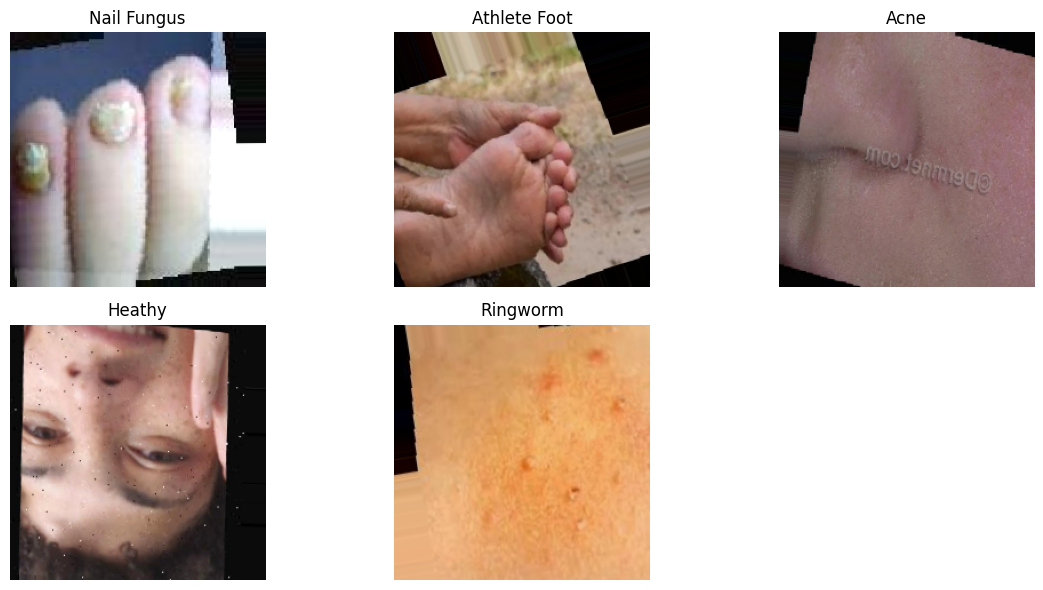

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load class indices (label → index mapping)
class_indices = training_set.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# Create a map to store one image per class
seen_classes = set()
images = []
labels = []

# Iterate over batches to collect one image per class
for i in range(len(training_set)):
    x_batch, y_batch = training_set[i]
    for img, label in zip(x_batch, y_batch):
        class_index = np.argmax(label)
        if class_index not in seen_classes:
            seen_classes.add(class_index)
            images.append(img)
            labels.append(index_to_class[class_index])
        if len(seen_classes) == len(index_to_class):
            break
    if len(seen_classes) == len(index_to_class):
        break

# Plot the collected images
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images) + 1) // 2, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")
plt.tight_layout()
plt.show()


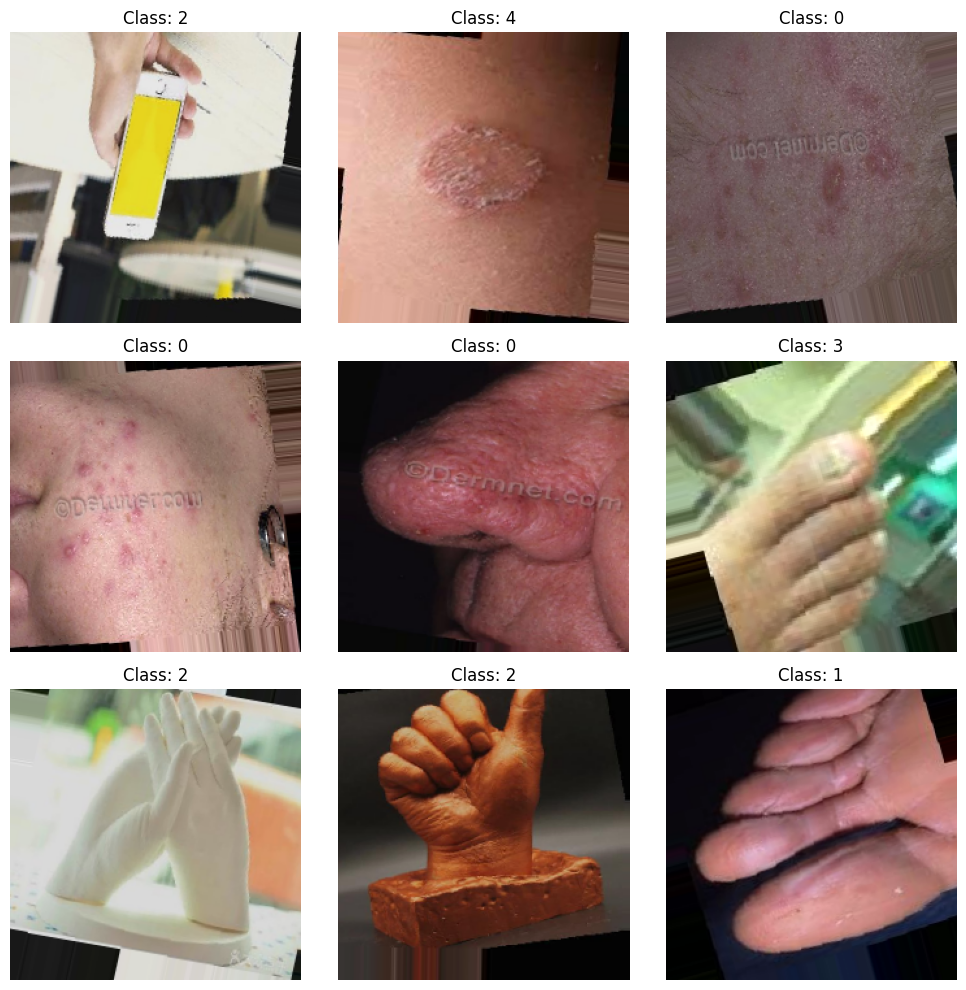

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the training set
images, labels = next(training_set)

# Show 9 augmented images
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class: {np.argmax(labels[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()


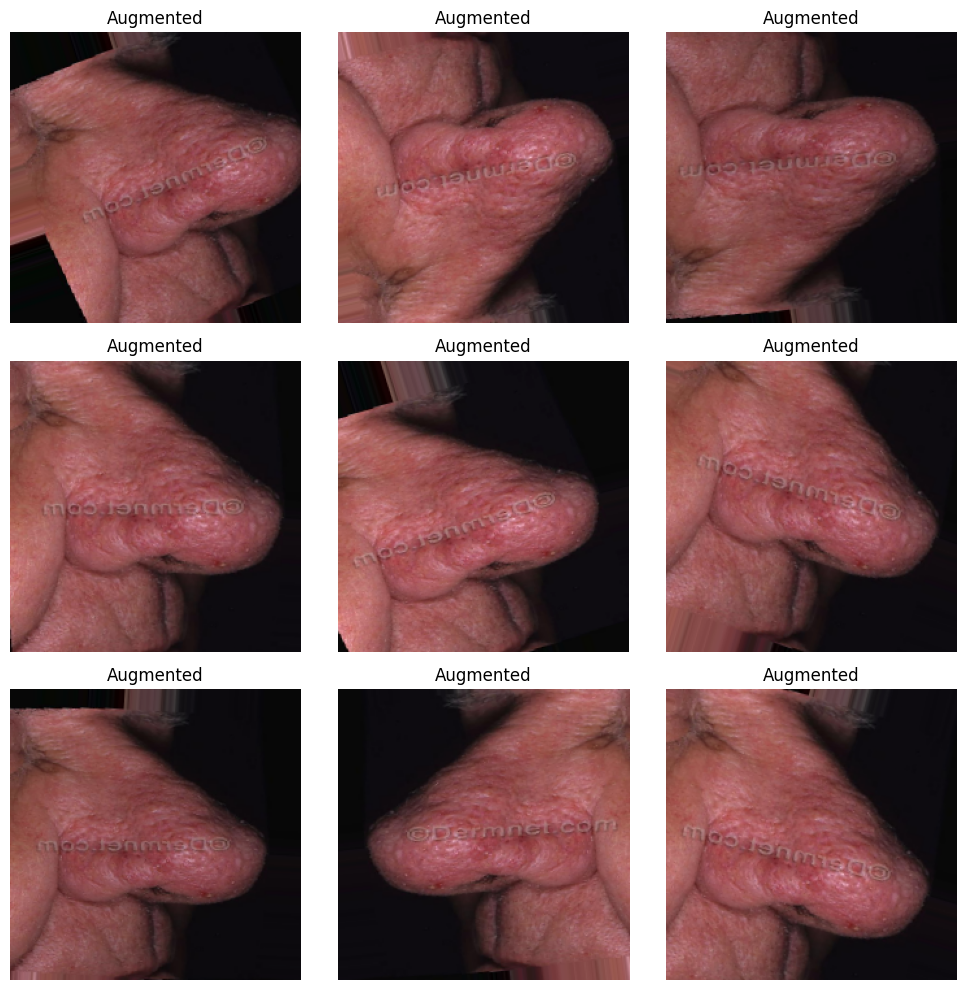

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Load a single image path
img_path = training_set.filepaths[0]
img = image.load_img(img_path, target_size=IMG_SIZE)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

# Show multiple augmented versions
plt.figure(figsize=(10, 10))
for i in range(9):
    augmented = datagen.flow(x, batch_size=1)
    aug_img = next(augmented)[0]  # single image in batch
    plt.subplot(3, 3, i + 1)
    plt.imshow(aug_img)
    plt.title("Augmented")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Building the CNN

In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint


# Load Pretrained MobileNetV2 (Exclude top layers)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = True
for layer in base_model.layers[:-40]: 
    layer.trainable = False



# Add Custom Classification Head
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])




# Train Model
callbacks = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
]

# Stage 1
base_model.trainable = False
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
history1 = model.fit(training_set, validation_data=test_set, epochs=10, callbacks=callbacks)
 
# Stage 2
base_model.trainable = True
model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model.fit(training_set, validation_data=test_set, epochs=20, callbacks=callbacks)



Epoch 1/10
1029/1029 [==============================] - 422s 401ms/step - loss: 0.1429 - accuracy: 0.9557 - val_loss: 0.0480 - val_accuracy: 0.9869 - lr: 0.0010
Epoch 2/10
1029/1029 [==============================] - 403s 391ms/step - loss: 0.0662 - accuracy: 0.9805 - val_loss: 0.0358 - val_accuracy: 0.9891 - lr: 0.0010
Epoch 3/10
1029/1029 [==============================] - 375s 365ms/step - loss: 0.0580 - accuracy: 0.9831 - val_loss: 0.0320 - val_accuracy: 0.9903 - lr: 0.0010
Epoch 4/10
1029/1029 [==============================] - 357s 346ms/step - loss: 0.0458 - accuracy: 0.9869 - val_loss: 0.0313 - val_accuracy: 0.9922 - lr: 0.0010
Epoch 5/10
1029/1029 [==============================] - 379s 368ms/step - loss: 0.0433 - accuracy: 0.9874 - val_loss: 0.0385 - val_accuracy: 0.9915 - lr: 0.0010
Epoch 6/10
1029/1029 [==============================] - 376s 366ms/step - loss: 0.0470 - accuracy: 0.9881 - val_loss: 0.0537 - val_accuracy: 0.9869 - lr: 0.0010
Epoch 7/10
1029/1029 [============

In [10]:
model.save("four_skin_disease_detection")

INFO:tensorflow:Assets written to: four_skin_disease_detection\assets


INFO:tensorflow:Assets written to: four_skin_disease_detection\assets


In [11]:
# Save the full model (includes weights, architecture, optimizer config)
model.save("four_skin_disease_detection.h5")  # Save as HDF5 file

In [ ]:
import tensorflow as tf

# Load saved model
saved_model_dir = "four_skin_disease_detection"

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)

# (Optional) Enable optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert and save
tflite_model = converter.convert()
with open("five_skin_disease_detection.tflite", "wb") as f:
    f.write(tflite_model)


In [3]:
import tensorflow as tf

# Use from_keras_model or from_saved_model depending on what you loaded
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Allow training on resource variables
converter.experimental_enable_resource_variables = True

# Include Select TF ops to support GradientTape and training ops
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,       # TFLite built-in ops
    tf.lite.OpsSet.SELECT_TF_OPS          # Full TF ops (required for training)
]

# Optional: Enable debugging info
converter._experimental_enable_batchmatmul_unfolding = True

# Convert
tflite_model = converter.convert()

# Save the TFLite model
with open("trainable_model.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp59v43rq1\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp59v43rq1\assets


In [ ]:
import tensorflow as tf

class TrainableModel(tf.Module):
    def __init__(self, keras_model):
        super().__init__()
        self.model = keras_model

        self.optimizer = tf.keras.optimizers.Adam()
        self.loss_fn = tf.keras.losses.CategoricalCrossentropy()

    @tf.function(input_signature=[tf.TensorSpec([None, 224, 224, 3], tf.float32),
                                  tf.TensorSpec([None, 6], tf.float32)])
    def train(self, x, y):
        with tf.GradientTape() as tape:
            predictions = self.model(x, training=True)
            loss = self.loss_fn(y, predictions)
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return {"loss": loss}

    @tf.function(input_signature=[tf.TensorSpec([None, 224, 224, 3], tf.float32)])
    def infer(self, x):
        return {"predictions": self.model(x, training=False)}

    @tf.function
    def save(self):
        tf.print("Save called (you can implement custom save logic if needed)")

    @tf.function
    def load(self):
        tf.print("Load called (you can implement custom load logic if needed)")


wrapped_model = TrainableModel(model)

tf.saved_model.save(
    wrapped_model,
    export_dir='five_skin_disease_detection',
    signatures={
        'train': wrapped_model.train.get_concrete_function(),
        'infer': wrapped_model.infer.get_concrete_function(),
        'save': wrapped_model.save.get_concrete_function(),
        'load': wrapped_model.load.get_concrete_function(),
    }
)
converter = tf.lite.TFLiteConverter.from_saved_model("five_skin_disease_detection")
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,     # Use TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS        # Also allow full TF ops (e.g., GradientTape)
]
converter.experimental_enable_resource_variables = True
tflite_model = converter.convert()



In [ ]:
with open("retrainable_model.tflite", "wb") as f:
    f.write(tflite_model)


In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,     # Use TFLite ops
    tf.lite.OpsSet.SELECT_TF_OPS        # Also allow full TF ops (e.g., GradientTape)
]
converter.experimental_enable_resource_variables = True
tflite_model = converter.convert()

with open("retrainable_model.tflite", "wb") as f:
    f.write(tflite_model)


In [13]:
# Training progress
# Combine history from both stages
import pandas as pd

combined_history = {}
for key in history1.history:
    combined_history[key] = history1.history[key] + history2.history[key]



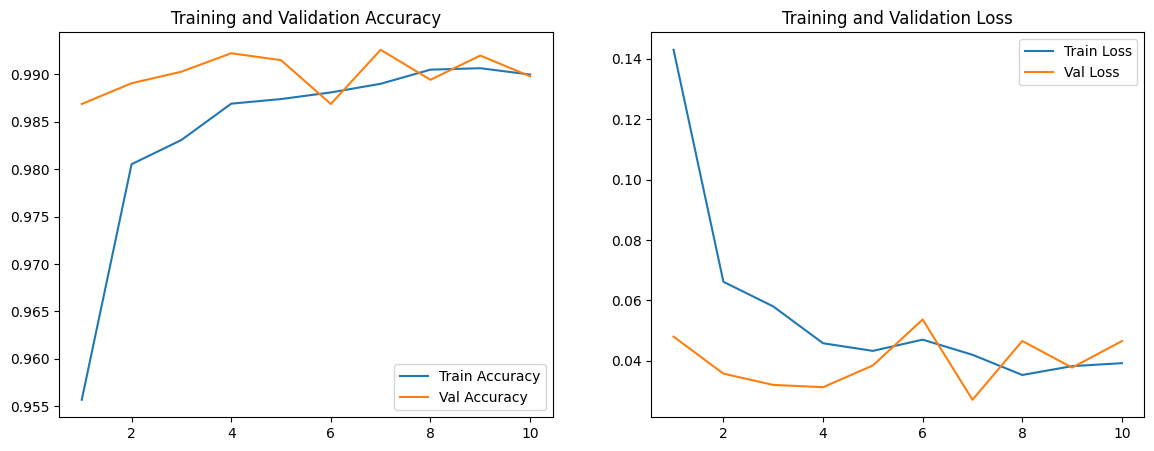

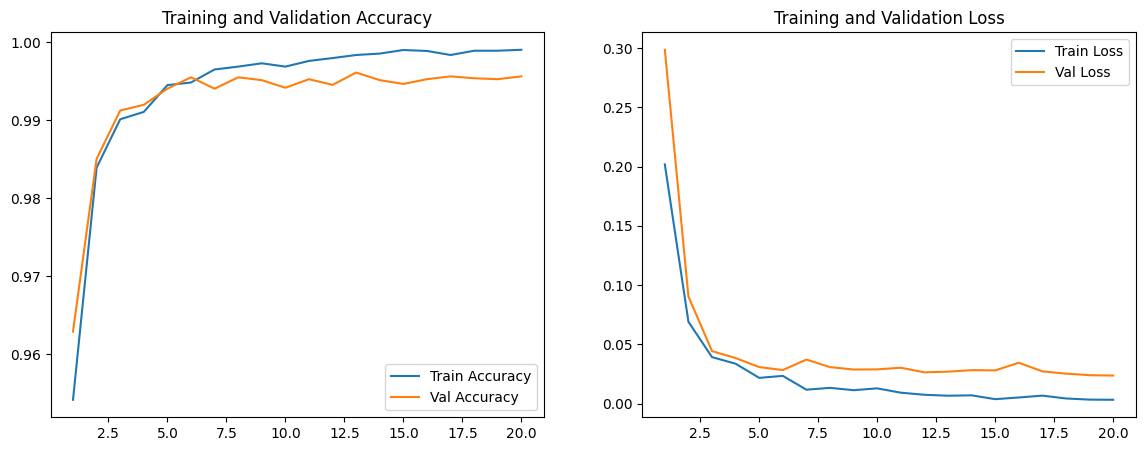

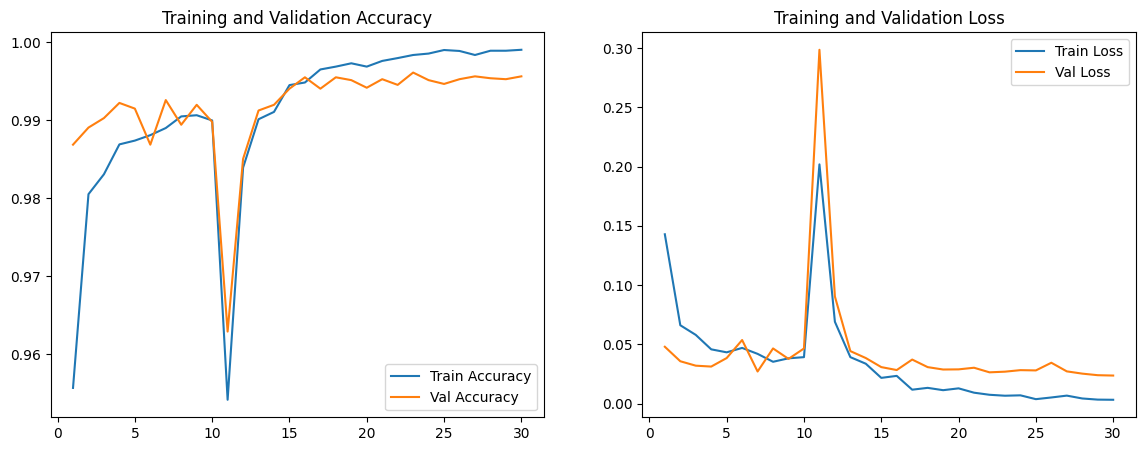

In [14]:
# Training progress
import matplotlib.pyplot as plt

def plot_history(history_dict):
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()

# Use for single stage:
plot_history(history1.history)
plot_history(history2.history)

# Or for combined:
plot_history(combined_history)


1/1 [==============================] - 0s 26ms/step


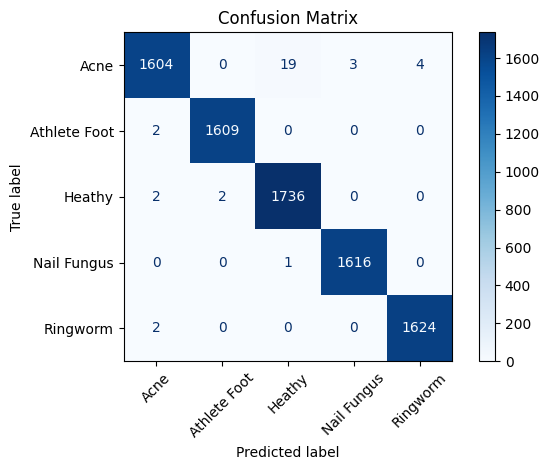

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get true labels and predictions
Y_true = []
Y_pred = []

# Go through test batches and collect predictions
for i in range(len(test_set)):
    x_batch, y_batch = test_set[i]
    y_pred_batch = model.predict(x_batch)
    
    Y_true.extend(np.argmax(y_batch, axis=1))
    Y_pred.extend(np.argmax(y_pred_batch, axis=1))

    if (i + 1) * test_set.batch_size >= test_set.samples:
        break  # Stop if we've processed all test data

# 2. Compute confusion matrix
cm = confusion_matrix(Y_true, Y_pred)
labels = list(test_set.class_indices.keys())  # Class names

# 3. Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# --- 1. Load the TFLite Model ---
interpreter = tf.lite.Interpreter(model_path="299-model-test-v5.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# --- 2. Set Up Test Data (already defined by you) ---
# test_set is already created using validation_split=0.2

# --- 3. Run Inference on test_set ---
Y_true = []
Y_pred = []

# Go through all batches
for i in range(len(test_set)):
    x_batch, y_batch = test_set[i]
    
    for img, true_label in zip(x_batch, y_batch):
        img = np.expand_dims(img.astype(np.float32), axis=0)  # (1, 224, 224, 3)

        interpreter.set_tensor(input_details[0]['index'], img)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        pred_label = np.argmax(output[0])
        true_label = np.argmax(true_label)

        Y_pred.append(pred_label)
        Y_true.append(true_label)

    # Break when all validation samples are processed
    if (i + 1) * test_set.batch_size >= test_set.samples:
        break

# --- 4. Plot Confusion Matrix ---
labels = list(test_set.class_indices.keys())

cm = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (TFLite Model on Validation Data)")
plt.tight_layout()
plt.show()


RuntimeError: CPU dispatcher tracer already initlized

ImportError: numpy._core.multiarray failed to import

In [13]:
# eval_datagen = ImageDataGenerator(rescale=1./255)

# eval_set = eval_datagen.flow_from_directory(
#     'C:/Users/User/Downloads/6_skin_diseases/kaggle/val',
#     target_size=(128, 128),
#     batch_size=64,
#     class_mode='categorical',
#     shuffle=False  # Important: keep order for correct confusion matrix
# )
# import numpy as np
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# # Predict
# y_true = eval_set.classes
# y_pred_probs = model.predict(eval_set)
# y_pred = np.argmax(y_pred_probs, axis=1)

# # Class names
# class_labels = list(eval_set.class_indices.keys())

# # Confusion matrix
# cm = confusion_matrix(y_true, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
# disp.plot(cmap='Blues', xticks_rotation=45)
# plt.title("Confusion Matrix on Custom Eval Folder")
# plt.tight_layout()
# plt.show()


In [14]:
model.save('299-model-test-v5.h5')

In [15]:
print(training_set.class_indices)

{'Acne': 0, 'Athlete Foot': 1, 'Heathy': 2, 'Nail Fungus': 3, 'Psoriasis': 4, 'Ringworm': 5}


In [ ]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('299-model-test-v5.h5')


In [17]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array  # ✅ Modern import

# Load and preprocess the image
test_image = load_img('C:/Users/User/Downloads/Skin-disease-dataset/single-prediction/acne3.jpeg', target_size=(224, 224))
test_image = img_to_array(test_image) / 255.0 
test_image = np.expand_dims(test_image, axis=0)


# Predict using the CNN model
result = model.predict(test_image)

# Define class labels in the same order as training_set.class_indices
# class_labels = [
#     "Acne",
#     "Athlete Foot",
#     "Heathy"
#     "Nail Fungus",
#     "Psoriasis",
#     "Rigworm"
# ]
class_labels = list(training_set.class_indices.keys())
print("Class labels:", class_labels)
# Get the predicted class index
predicted_index = np.argmax(result[0])
prediction = class_labels[predicted_index]

print("Probabilities:", result[0])
print("Predicted class:", prediction)
conf = np.max(result[0])
if conf < 0.4:
    print("⚠️ Low confidence: possible novel or unclear condition")
print("\nClass-wise probabilities:")

for i, prob in enumerate(result[0]):
    print(f"{class_labels[i]}: {prob * 100:.2f}%")


1/1 [==============================] - 1s 547ms/step
Class labels: ['Acne', 'Athlete Foot', 'Heathy', 'Nail Fungus', 'Psoriasis', 'Ringworm']
Probabilities: [9.99993086e-01 1.32661716e-14 5.49984369e-16 6.87180673e-13
 6.96500592e-06 1.69189484e-15]
Predicted class: Acne

Class-wise probabilities:
Acne: 100.00%
Athlete Foot: 0.00%
Heathy: 0.00%
Nail Fungus: 0.00%
Psoriasis: 0.00%
Ringworm: 0.00%


In [2]:
# Converting Model to TensorFlow Lite Format

import tensorflow as tf

# Step 1: Load your trained .h5 model
model = tf.keras.models.load_model('299-model-test-v5.h5')

# Step 2: Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Step 3: Save the converted .tflite model to disk
with open('299-model-test-v5.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Conversion successful. Saved as 299-model-test-v5.tflite")


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpdgn2r902\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpdgn2r902\assets


✅ Conversion successful. Saved as 299-model-test-v5.tflite


In [13]:
# Test the TFLite model

import numpy as np
import tensorflow as tf
from PIL import Image

# Load and preprocess image
def preprocess_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))  # match your model input size
    img = np.array(img).astype(np.float32) / 255.0  # normalize to [0,1]
    img = np.expand_dims(img, axis=0)  # add batch dimension
    return img

image_path = 'C:/Users/User/Downloads/Skin-disease-dataset/single-prediction/nf5.jpg'  # Replace with your image
input_data = preprocess_image(image_path)

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="299-model-test-v5.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], input_data)

# Run inference
interpreter.invoke()

# Get output tensor
output_data = interpreter.get_tensor(output_details[0]['index'])
print("Predicted probabilities:", output_data)

class_labels = ['Acne', 'Athlete Foot', 'Healthy', 'Nail Fungus', 'Psoriasis', 'Ringworm']  # your class list
predicted_index = np.argmax(output_data)
predicted_label = class_labels[predicted_index]
print("Predicted class:", predicted_label)



Predicted probabilities: [[1.5090137e-02 1.1927145e-05 3.6550517e-04 1.1366172e-06 9.8452950e-01
  1.8593090e-06]]
Predicted class: Psoriasis


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image  # import this module
import numpy as np

# Create a new model that outputs features before the classification layer
feature_extractor = Model(inputs=model.input,
                          outputs=model.layers[-2].output)  # usually GlobalAveragePooling2D layer

# Load and preprocess your image
img = image.load_img('C:/Users/User/Downloads/Skin-disease-dataset/single-prediction/nf5.jpg', target_size=(224, 224))  # load image
img_array = image.img_to_array(img)                              # convert to numpy array

# Preprocess the image array for MobileNetV2
img_array = preprocess_input(img_array)  

# Expand dims to make batch size = 1
img_array = np.expand_dims(img_array, axis=0)

# Get feature vector
features = feature_extractor.predict(img_array)

print("Extracted features shape:", features.shape)
print("Feature vector:", features)


1/1 [==============================] - 1s 567ms/step
Extracted features shape: (1, 256)
Feature vector: [[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          2.304142
   0.          0.          0.          0.          2.2198308   6.0931916
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.         12.723303    0.          0.
   0.          0.         10.139357    0.5229047   0.          0.
   0.          0.          8.529742    0.          0.          0.
   1.2057936   8.488004    1.1031747   0.          0.          0.
   0.          0.        

0 input_2 [(None, 224, 224, 3)]
1 Conv1 (None, 112, 112, 32)
2 bn_Conv1 (None, 112, 112, 32)
3 Conv1_relu (None, 112, 112, 32)
4 expanded_conv_depthwise (None, 112, 112, 32)
5 expanded_conv_depthwise_BN (None, 112, 112, 32)
6 expanded_conv_depthwise_relu (None, 112, 112, 32)
7 expanded_conv_project (None, 112, 112, 16)
8 expanded_conv_project_BN (None, 112, 112, 16)
9 block_1_expand (None, 112, 112, 96)
10 block_1_expand_BN (None, 112, 112, 96)
11 block_1_expand_relu (None, 112, 112, 96)
12 block_1_pad (None, 113, 113, 96)
13 block_1_depthwise (None, 56, 56, 96)
14 block_1_depthwise_BN (None, 56, 56, 96)
15 block_1_depthwise_relu (None, 56, 56, 96)
16 block_1_project (None, 56, 56, 24)
17 block_1_project_BN (None, 56, 56, 24)
18 block_2_expand (None, 56, 56, 144)
19 block_2_expand_BN (None, 56, 56, 144)
20 block_2_expand_relu (None, 56, 56, 144)
21 block_2_depthwise (None, 56, 56, 144)
22 block_2_depthwise_BN (None, 56, 56, 144)
23 block_2_depthwise_relu (None, 56, 56, 144)
24 block_2_

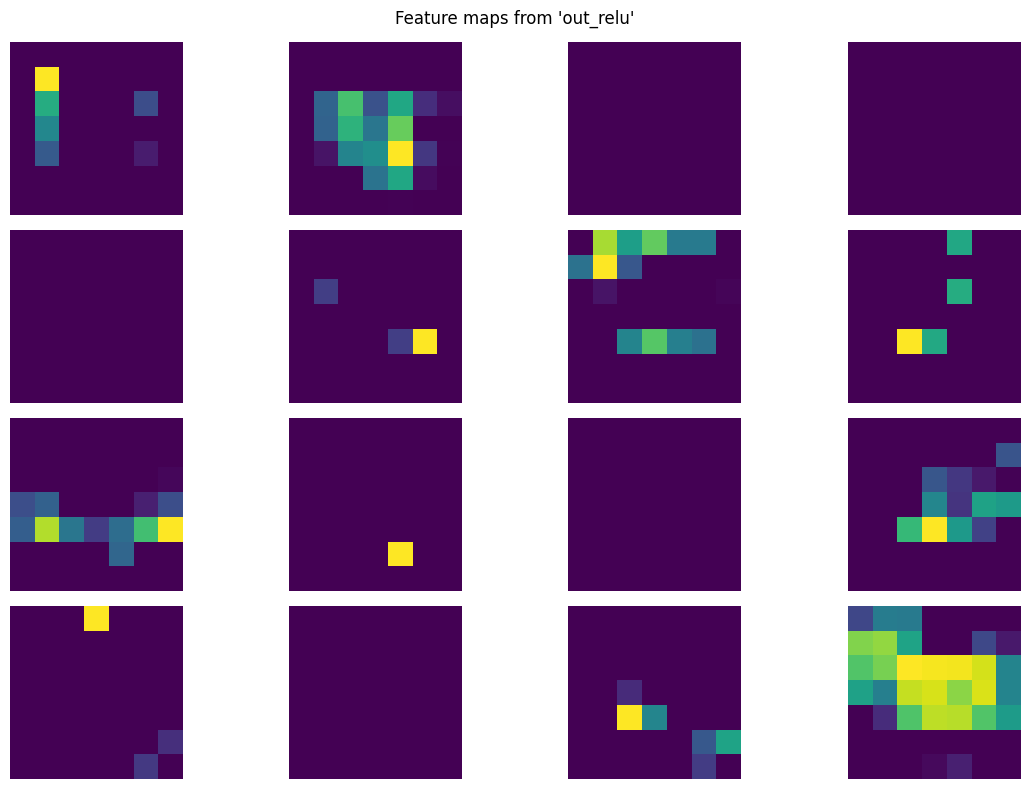

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing import image

# 1. Build base model
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,   # exclude final classification layers
                         weights='imagenet')

# 2. Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global average pooling reduces tensor dims
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(6, activation='softmax')(x)  # Assuming 6 classes

# 3. Create the full model
model = Model(inputs=base_model.input, outputs=output)

# (You would normally compile and train the model here)

# --------------------------------------------------------
# Now: Extract feature maps from an internal layer of base_model

# 4. Check internal layers of base_model
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.output_shape)

# 5. Choose a layer to extract features from
layer_name = 'out_relu'  # example internal layer of MobileNetV2

# 6. Create intermediate model
intermediate_model = Model(inputs=base_model.input,
                           outputs=base_model.get_layer(layer_name).output)

# --------------------------------------------------------
# 7. Load and preprocess an image
img_path = 'C:/Users/User/Downloads/Skin-disease-dataset/single-prediction/acne1.jpeg'  # Replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)  # batch dimension

# --------------------------------------------------------
# 8. Predict feature maps
feature_maps = intermediate_model.predict(img_array)
print("Feature maps shape:", feature_maps.shape)  # e.g. (1, 14, 14, 96)

# --------------------------------------------------------
# 9. Visualize first 16 feature maps
plt.figure(figsize=(12, 8))
for i in range(min(16, feature_maps.shape[-1])):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f"Feature maps from '{layer_name}'")
plt.tight_layout()
plt.show()
